#Denoising Diffusion Probabilistic Model (DDPM)

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Oct  1 14:21:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

![model type diag](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/generative-overview.png)
Overview of different types of generative models. (from [this great blog post](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/))

In [ ]:
!pip install -U datasets huggingface_hub

  Using cached huggingface_hub-2.1.1-py3-none-any.whl.metadata (16 kB)


In [ ]:
from datasets import load_dataset
from PIL import Image
import torch.nn.functional as F
import os
from tqdm.notebook import tqdm
import torch
import numpy as np


def img_to_tensor(im):
  return torch.tensor(np.array(im.convert('RGB'))/255).permute(2, 0, 1).unsqueeze(0) * 2 - 1

def tensor_to_image(t):
  return Image.fromarray(np.array(((t.squeeze().permute(1, 2, 0)+1)/2).clip(0, 1)*255).astype(np.uint8))

def gather(consts: torch.Tensor, t: torch.Tensor):
    """Gather consts for $t$ and reshape to feature map shape"""
    c = consts.gather(-1, t)
    return c.reshape(-1, 1, 1, 1)

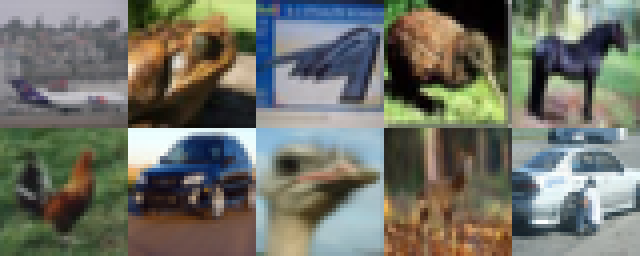

In [ ]:
#@title cifar10 - 32px images in 10 classes

# Download and load the dataset
cifar10 = load_dataset('uoft-cs/cifar10')

# View some examples:
image = Image.new('RGB', size=(32*5, 32*2))
for i in range(10):
  im = cifar10['train'][i]['img']
  image.paste(im, ( (i%5)*32, (i//5)*32 ))
image.resize((32*5*4, 32*2*4), Image.NEAREST)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

$q(\mathbf{x}_t \vert \mathbf{x}_{t-1}) = \mathcal{N}(\mathbf{x}_t; \sqrt{1 - \beta_t} \mathbf{x}_{t-1}, \beta_t\mathbf{I}) \quad
q(\mathbf{x}_{1:T} \vert \mathbf{x}_0) = \prod^T_{t=1} q(\mathbf{x}_t \vert \mathbf{x}_{t-1})$

/tmp/ipykernel_1819/1208923197.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return Image.fromarray(np.array(((t.squeeze().permute(1, 2, 0)+1)/2).clip(0, 1)*255).astype(np.uint8))


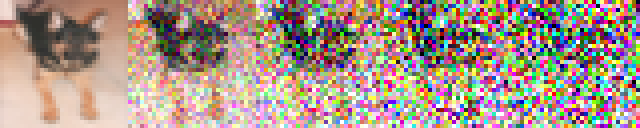

In [ ]:
n_steps = 100
beta = torch.linspace(0.0001, 0.04, n_steps).to(device)

import torch.distributions as dist
def q_xt_xtminus1(xtm1, t):

    c, h, w = xtm1.shape
    xtm1 = xtm1.to(device)

    eta = torch.randn(c, h, w).to(device)

    noisy = (1 - beta[t]).sqrt().reshape(1, 1, 1) * xtm1 + beta[t].sqrt().reshape(1, 1, 1) * eta
    return noisy
    return sample
ims = []
start_im = cifar10['train'][10]['img']
x = img_to_tensor(start_im).squeeze()
for t in range(n_steps):
  if t%20 == 0:
    ims.append(tensor_to_image(x.cpu()))
  t = torch.tensor(t, dtype=torch.long) # t as a tensor
  x = q_xt_xtminus1(x, t) # Modify x using our function above
image = Image.new('RGB', size=(32*5, 32))
for i, im in enumerate(ims):
  image.paste(im, ((i%5)*32, 0))
image.resize((32*4*5, 32*4), Image.NEAREST)

/tmp/ipykernel_1819/1208923197.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return Image.fromarray(np.array(((t.squeeze().permute(1, 2, 0)+1)/2).clip(0, 1)*255).astype(np.uint8))


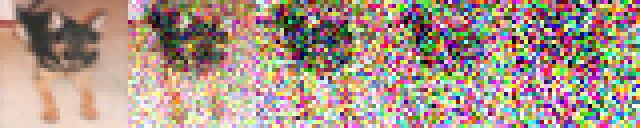

In [ ]:
n_steps = 100
beta = torch.linspace(0.0001, 0.04, n_steps).to(device)
alpha = 1. - beta
alpha_bar = torch.cumprod(alpha, dim=0)

def q_xt_x0(x0, t):
    c, h, w = x0.shape
    a_bar = alpha_bar[t]
    x0 = x0.to(device)

    eta = torch.randn(c, h, w).to(device)

    noisy = a_bar.sqrt().reshape(1, 1, 1) * x0 + (1 - a_bar).sqrt().reshape(1, 1, 1) * eta
    return noisy
ims = []
start_im = cifar10['train'][10]['img']
x0 = img_to_tensor(start_im).squeeze()
for t in [0, 20, 40, 60, 80]:
  x = q_xt_x0(x0, torch.tensor(t, dtype=torch.long))
  ims.append(tensor_to_image(x.cpu()))

image = Image.new('RGB', size=(32*5, 32))
for i, im in enumerate(ims):
  image.paste(im, ((i%5)*32, 0))
image.resize((32*4*5, 32*4), Image.NEAREST)

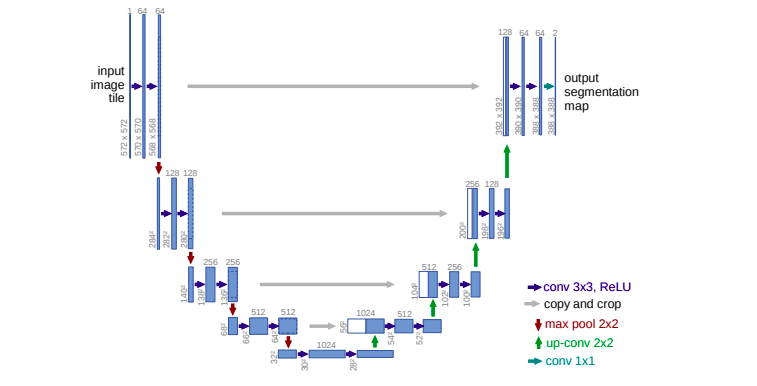

(Unet diagram from [the 2015 paper](https://arxiv.org/abs/1505.04597))

In [ ]:
import math
from typing import Optional, Tuple, Union, List

import torch
from torch import nn
class Swish(nn.Module):

    def forward(self, x):
        return x * torch.sigmoid(x)
class TimeEmbedding(nn.Module):

    def __init__(self, n_channels: int):
        super().__init__()
        self.n_channels = n_channels
        self.lin1 = nn.Linear(self.n_channels // 4, self.n_channels)
        self.act = Swish()
        self.lin2 = nn.Linear(self.n_channels, self.n_channels)

    def forward(self, t: torch.Tensor):
        half_dim = self.n_channels // 8
        emb = math.log(10_000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=1)
        emb = self.act(self.lin1(emb))
        emb = self.lin2(emb)
        return emb
class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, time_channels: int, n_groups: int = 32):
        super().__init__()
        self.norm1 = nn.GroupNorm(n_groups, in_channels)
        self.act1 = Swish()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=(3, 3), padding=(1, 1))
        self.norm2 = nn.GroupNorm(n_groups, out_channels)
        self.act2 = Swish()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=(3, 3), padding=(1, 1))
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=(1, 1))
        else:
            self.shortcut = nn.Identity()
        self.time_emb = nn.Linear(time_channels, out_channels)

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        h = self.conv1(self.act1(self.norm1(x)))
        h += self.time_emb(t)[:, :, None, None]
        h = self.conv2(self.act2(self.norm2(h)))
        return h + self.shortcut(x)
class AttentionBlock(nn.Module):

    def __init__(self, n_channels: int, n_heads: int = 1, d_k: int = None, n_groups: int = 32):
        super().__init__()
        if d_k is None:
            d_k = n_channels
        self.norm = nn.GroupNorm(n_groups, n_channels)
        self.projection = nn.Linear(n_channels, n_heads * d_k * 3)
        self.output = nn.Linear(n_heads * d_k, n_channels)
        self.scale = d_k ** -0.5
        self.n_heads = n_heads
        self.d_k = d_k

    def forward(self, x: torch.Tensor, t: Optional[torch.Tensor] = None):
        _ = t
        batch_size, n_channels, height, width = x.shape
        x = x.view(batch_size, n_channels, -1).permute(0, 2, 1)
        qkv = self.projection(x).view(batch_size, -1, self.n_heads, 3 * self.d_k)
        q, k, v = torch.chunk(qkv, 3, dim=-1)
        attn = torch.einsum('bihd,bjhd->bijh', q, k) * self.scale
        attn = attn.softmax(dim=1)
        res = torch.einsum('bijh,bjhd->bihd', attn, v)
        res = res.view(batch_size, -1, self.n_heads * self.d_k)
        res = self.output(res)
        res += x
        res = res.permute(0, 2, 1).view(batch_size, n_channels, height, width)
        return res


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, time_channels: int, has_attn: bool):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_channels)
        if has_attn:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        x = self.res(x, t)
        x = self.attn(x)
        return x


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, time_channels: int, has_attn: bool):
        super().__init__()
        self.res = ResidualBlock(in_channels + out_channels, out_channels, time_channels)
        if has_attn:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        x = self.res(x, t)
        x = self.attn(x)
        return x


class MiddleBlock(nn.Module):
    def __init__(self, n_channels: int, time_channels: int):
        super().__init__()
        self.res1 = ResidualBlock(n_channels, n_channels, time_channels)
        self.attn = AttentionBlock(n_channels)
        self.res2 = ResidualBlock(n_channels, n_channels, time_channels)

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        x = self.res1(x, t)
        x = self.attn(x)
        x = self.res2(x, t)
        return x


class Upsample(nn.Module):

    def __init__(self, n_channels):
        super().__init__()
        self.conv = nn.ConvTranspose2d(n_channels, n_channels, (4, 4), (2, 2), (1, 1))

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        _ = t
        return self.conv(x)


class Downsample(nn.Module):

    def __init__(self, n_channels):
        super().__init__()
        self.conv = nn.Conv2d(n_channels, n_channels, (3, 3), (2, 2), (1, 1))

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        _ = t
        return self.conv(x)

class UNet(nn.Module):

    def __init__(self, image_channels: int = 3, n_channels: int = 64,
                 ch_mults: Union[Tuple[int, ...], List[int]] = (1, 2, 2, 4),
                 is_attn: Union[Tuple[bool, ...], List[int]] = (False, False, True, True),
                 n_blocks: int = 2):
        super().__init__()
        n_resolutions = len(ch_mults)
        self.image_proj = nn.Conv2d(image_channels, n_channels, kernel_size=(3, 3), padding=(1, 1))
        self.time_emb = TimeEmbedding(n_channels * 4)
        down = []
        out_channels = in_channels = n_channels
        for i in range(n_resolutions):
            out_channels = in_channels * ch_mults[i]
            for _ in range(n_blocks):
                down.append(DownBlock(in_channels, out_channels, n_channels * 4, is_attn[i]))
                in_channels = out_channels
            if i < n_resolutions - 1:
                down.append(Downsample(in_channels))
        self.down = nn.ModuleList(down)
        self.middle = MiddleBlock(out_channels, n_channels * 4, )
        up = []
        in_channels = out_channels
        for i in reversed(range(n_resolutions)):
            out_channels = in_channels
            for _ in range(n_blocks):
                up.append(UpBlock(in_channels, out_channels, n_channels * 4, is_attn[i]))
            out_channels = in_channels // ch_mults[i]
            up.append(UpBlock(in_channels, out_channels, n_channels * 4, is_attn[i]))
            in_channels = out_channels
            if i > 0:
                up.append(Upsample(in_channels))

        self.up = nn.ModuleList(up)

        self.norm = nn.GroupNorm(8, n_channels)
        self.act = Swish()
        self.final = nn.Conv2d(in_channels, image_channels, kernel_size=(3, 3), padding=(1, 1))

    def forward(self, x: torch.Tensor, t: torch.Tensor):

        t = self.time_emb(t)

        x = self.image_proj(x)

        h = [x]
        for m in self.down:
            x = m(x, t)
            h.append(x)
        x = self.middle(x, t)
        for m in self.up:
            if isinstance(m, Upsample):
                x = m(x, t)
            else:
                s = h.pop()
                x = torch.cat((x, s), dim=1)
                #
                x = m(x, t)

        return self.final(self.act(self.norm(x)))

In [ ]:
x = torch.randn(10, 3, 32, 32)

t = torch.tensor([50.], dtype=torch.long)

unet = UNet()

model_output = unet(x, t)

model_output.shape

torch.Size([10, 3, 32, 32])

In [ ]:

unet = UNet(n_channels=32).cuda()

n_steps = 1000
beta = torch.linspace(0.0001, 0.04, n_steps).cuda()
alpha = 1. - beta
alpha_bar = torch.cumprod(alpha, dim=0)

def q_xt_x0(x0, t):

    n, c, h, w = x0.shape
    x0 = x0.cuda()
    eps = torch.randn(n, c, h, w).to(device)

    a_bar = alpha_bar[t]

    noisy = a_bar.sqrt().reshape(n, 1, 1, 1) * x0 + (1 - a_bar).sqrt().reshape(n, 1, 1, 1) * eps
    return noisy, eps

batch_size = 128
lr = 7e-5

losses = []
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset


def getTransforms():
    return  transforms.Compose([
        transforms.ToTensor(),
    ])

class CIFAR10Dataset(Dataset):
    def __init__(self, transforms=None):
        super(CIFAR10Dataset, self).__init__()
        self.transforms = transforms

    def __len__(self):
        return len(cifar10['train'])


    def __getitem__(self, index):
        image = cifar10['train'][index]['img']
        image = self.transforms(image)
        return image

my_transforms = getTransforms()
dataset = CIFAR10Dataset(my_transforms)
data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
optim = torch.optim.Adam(unet.parameters(), lr=lr)



In [ ]:


epochs = 30
epoch_loss = []

for epoch in tqdm(range(1, epochs + 1)):
    average_train_loss = 0
    loop_train = tqdm(enumerate(data_loader, 1), total=len(data_loader), desc="Train", position=0, leave=True)
    for index, x0 in loop_train:
      optim.zero_grad()
      t = torch.randint(0, n_steps, (x0.shape[0],), dtype=torch.long).cuda()

      xt, noise = q_xt_x0(x0, t)

      pred_noise = unet(xt.float(), t)
      loss = F.mse_loss(noise.float(), pred_noise)
      losses.append(loss.item())
      average_train_loss+=loss.item()

      loss.backward()
      optim.step()

      loop_train.set_description(f"Train - iteration : {epoch}")
      loop_train.set_postfix(
          avg_train_loss="{:.4f}".format(average_train_loss / index),
          refresh=True,
      )
    epoch_loss.append(average_train_loss / len(data_loader))

torch.save(unet.state_dict(), "/content/unit.pt")


  0%|          | 0/30 [00:00<?, ?it/s]

Train:   0%|          | 0/391 [00:00<?, ?it/s]

Train:   0%|          | 0/391 [00:00<?, ?it/s]

Train:   0%|          | 0/391 [00:00<?, ?it/s]

Train:   0%|          | 0/391 [00:00<?, ?it/s]

...

Train:   0%|          | 0/391 [00:00<?, ?it/s]

Train:   0%|          | 0/391 [00:00<?, ?it/s]

Train:   0%|          | 0/391 [00:00<?, ?it/s]

Train:   0%|          | 0/391 [00:00<?, ?it/s]

Train:   0%|          | 0/391 [00:00<?, ?it/s]

## Iteration Loss

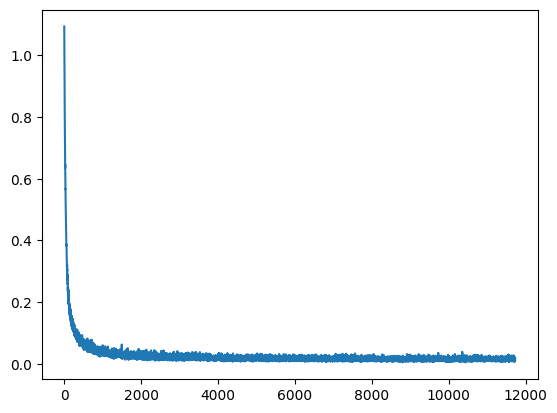

In [ ]:
from matplotlib import pyplot as plt
plt.plot(losses)

## Epoch Loss

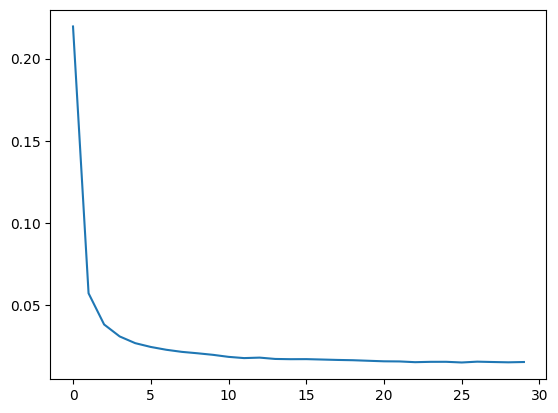

In [ ]:
from matplotlib import pyplot as plt
plt.plot(epoch_loss)

## 2.5 The Reverse Step

In [ ]:
def p_xt(xt, noise, t):
    alpha_t = alpha[t]
    alpha_bar_t = alpha_bar[t]
    eps_coef = (1 - alpha_t) / (1 - alpha_bar_t) ** .5
    mean = 1 / (alpha_t ** 0.5) * (xt - eps_coef * noise)
    var = beta[t]
    eps = torch.randn(xt.shape, device=device)
    return mean + (var ** 0.5) * eps


In [ ]:
x = torch.randn(1, 3, 32, 32).cuda()
ims = []

model = UNet(n_channels=32).cuda()
model.load_state_dict(torch.load("/content/unit.pt"))  # check filename
model.eval()

for i in range(1, n_steps + 1):
    t = torch.tensor(n_steps - i, dtype=torch.long).cuda().unsqueeze(0)

    with torch.no_grad():
        predictions = model(x.float(), t)

    x = p_xt(x, predictions, t)

    if i % 200 == 0:
        ims.append(tensor_to_image(x.cpu()))

/tmp/ipykernel_1819/1208923197.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return Image.fromarray(np.array(((t.squeeze().permute(1, 2, 0)+1)/2).clip(0, 1)*255).astype(np.uint8))


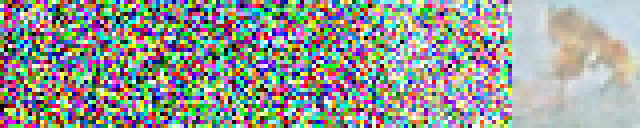

In [ ]:
image = Image.new('RGB', size=(32*5, 32))
for i, im in enumerate(ims[:5]):
  image.paste(im, ((i%5)*32, 0))
image.resize((32*4*5, 32*4), Image.NEAREST)

In [ ]:

x = torch.randn(100, 3, 32, 32).cuda()
ims = []
for i in range(n_steps):
  t = torch.tensor(n_steps-i-1, dtype=torch.long).cuda()
  with torch.no_grad():
    pred_noise = unet(x.float(), t.unsqueeze(0))
    x = p_xt(x, pred_noise, t.unsqueeze(0))

/tmp/ipykernel_1819/1208923197.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return Image.fromarray(np.array(((t.squeeze().permute(1, 2, 0)+1)/2).clip(0, 1)*255).astype(np.uint8))


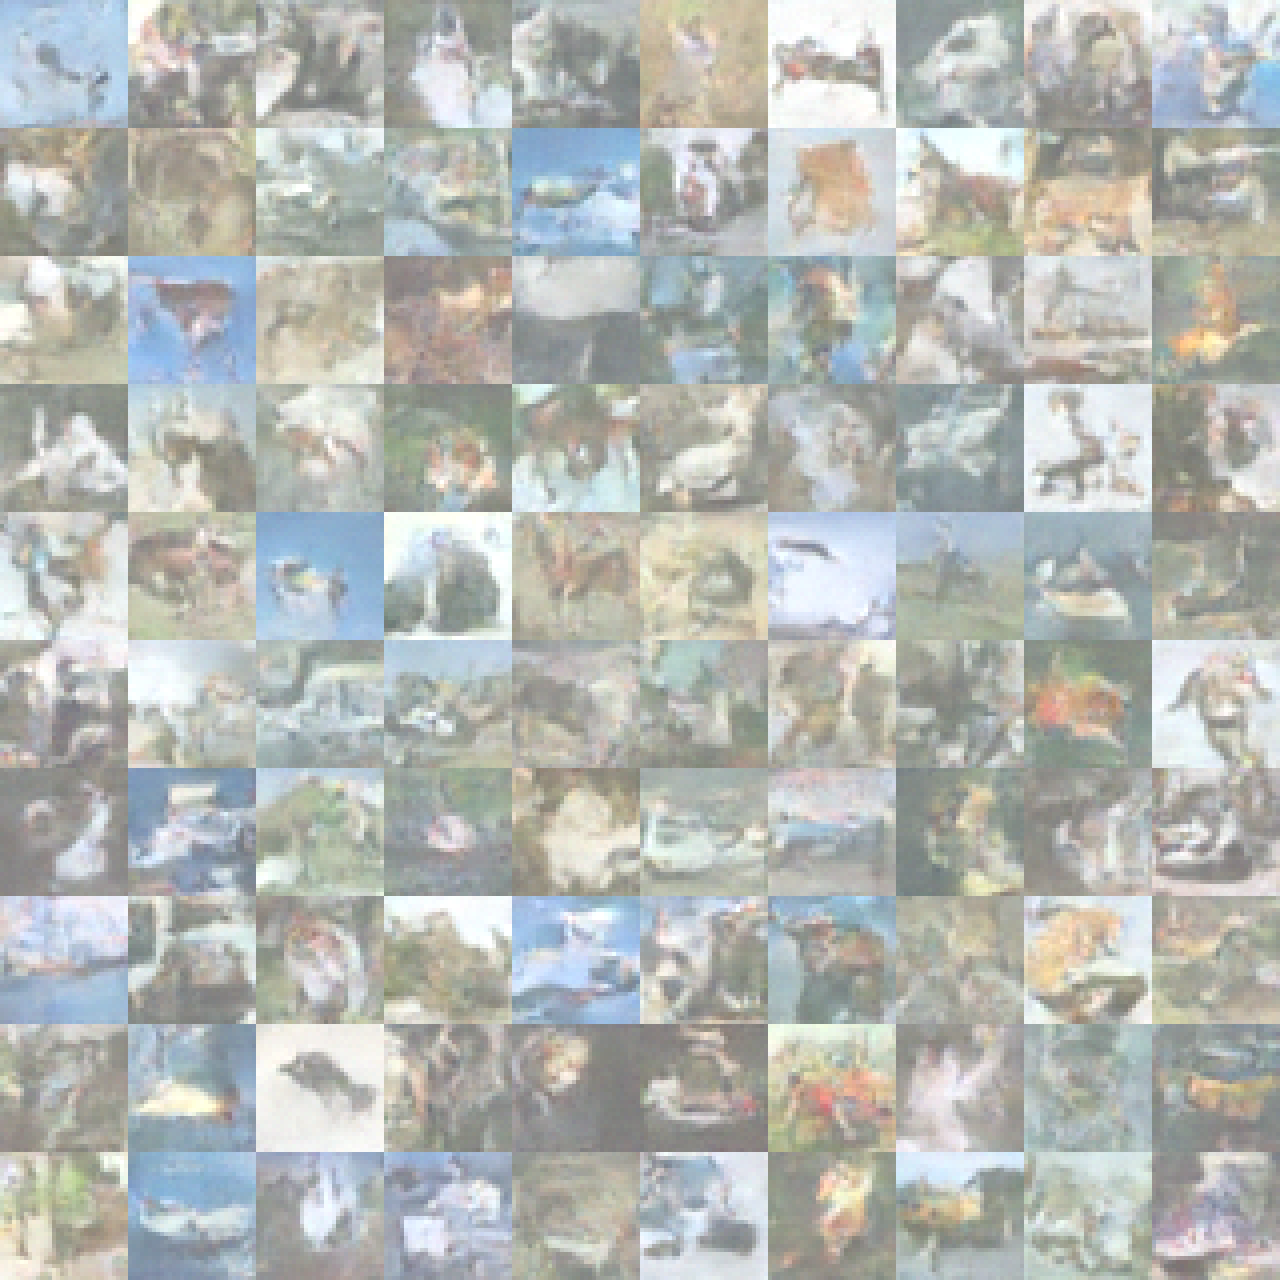

In [ ]:
for i in range(100):
  ims.append(tensor_to_image(x[i].unsqueeze(0).cpu()))

image = Image.new('RGB', size=(32*10, 32*10))
for i, im in enumerate(ims):
  image.paste(im, ((i%10)*32, 32*(i//10)))
image.resize((32*4*10, 32*4*10), Image.NEAREST)